In [1]:
# Installation des versions stables pour ton PFE
!pip install scikeras scikit-learn==1.5.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 88.8 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.41 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


Chargement des données...
Création d'un échantillon de 15000 lignes pour l'optimisation...

--- DÉBUT DU GRID SEARCH (Deep Learning Corrigé) ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
-> Meilleur R² DL: 0.4853 (en 226.5s)
-> Meilleurs Params: {'model__learning_rate': 0.001, 'model__n_layers': 3, 'model__n_neurons': 128}

Génération des graphiques de performance...


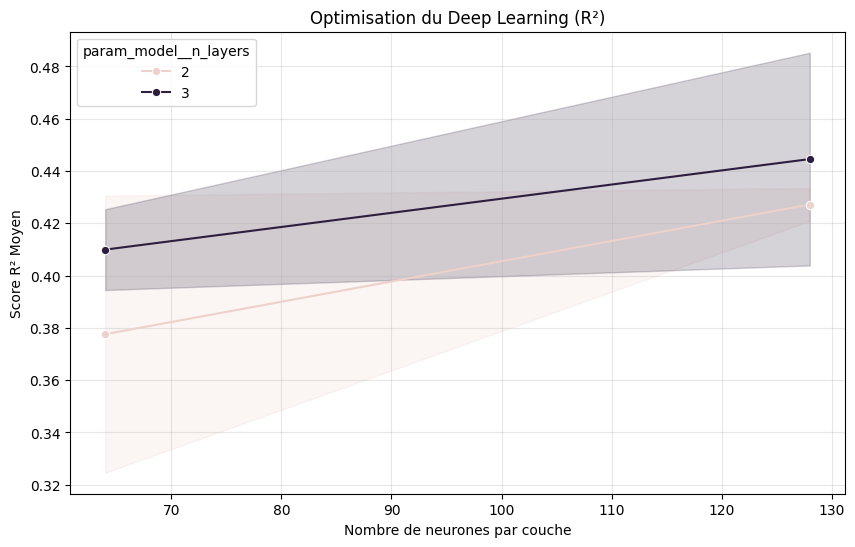

🏆 MEILLEURE ARCHITECTURE DL : {'model__learning_rate': 0.001, 'model__n_layers': 3, 'model__n_neurons': 128}

Lancement de l'entraînement FINAL sur 359201 lignes...
Epoch 1/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 786.4714
Epoch 2/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 74.1340
Epoch 3/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 66.4403
Epoch 4/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 63.0733
Epoch 5/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 61.6918
Epoch 6/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 59.0843
Epoch 7/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 57.5442
Epoch 8/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 55.1576
Epoch 9/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 54.4827
Epoch 10/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 52.4037
Epoch 11/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 51.7013
Epoch 12/50
1404/1404 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss:

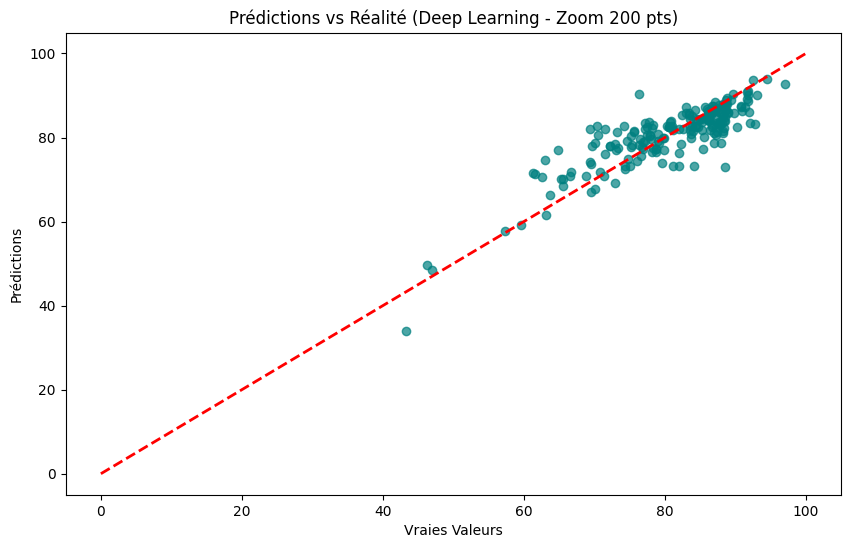


Sauvegarde du modèle DL et du scaler...
✅ Sauvegarde terminée : 'best_model_dl_tuned.pkl' et 'scaler_dl_tuned.pkl'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

# TensorFlow & SciKeras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =================================================================
# 0. CORRECTIF DE COMPATIBILITÉ (POUR ÉVITER L'ERREUR TAGS)
# =================================================================
class CompatibleKerasRegressor(KerasRegressor):
    """Version corrigée du wrapper pour Scikit-Learn 1.6+"""
    def __sklearn_tags__(self):
        from sklearn.utils._estimator_tags import EstimatorTags
        tags = EstimatorTags()
        tags.regressor_tags.predict_2d = True
        return tags

# =================================================================
# 1. CHARGEMENT ET PRÉPARATION
# =================================================================
print("Chargement des données...")
# Assure-toi que le fichier est bien présent dans ton répertoire Colab
df = pd.read_csv('data_ready_to_use.csv')

target_col = "LIT_002_FILTER_WATER_STG_TNK"

try:
    target_index = df.columns.get_loc(target_col)
    X = df.iloc[:, :target_index]
    y = df[target_col]
except KeyError:
    print(f"Erreur : Cible '{target_col}' introuvable.")
    exit()

# Scaling (Vital pour la convergence du réseau de neurones)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =================================================================
# 2. ÉCHANTILLONNAGE POUR GRID SEARCH
# =================================================================
SAMPLE_SIZE = 15000
print(f"Création d'un échantillon de {SAMPLE_SIZE} lignes pour l'optimisation...")
indices_sample = np.random.choice(X.shape[0], SAMPLE_SIZE, replace=False)
X_sample = X_scaled[indices_sample]
y_sample = y.iloc[indices_sample]

# =================================================================
# 3. DÉFINITION DU MODÈLE ET DE LA GRILLE
# =================================================================
def create_dl_model(n_layers=2, n_neurons=64, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))
    for _ in range(n_layers):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

# Utilisation de la classe corrigée 'CompatibleKerasRegressor'
dl_model = CompatibleKerasRegressor(
    model=create_dl_model,
    epochs=20,
    batch_size=128,
    verbose=0,
    n_layers=2,
    n_neurons=64,
    learning_rate=0.001
)

param_grid = {
    'model__n_layers': [2, 3],
    'model__n_neurons': [64, 128],
    'model__learning_rate': [0.01, 0.001]
}

# =================================================================
# 4. EXÉCUTION DU GRID SEARCH
# =================================================================
print("\n--- DÉBUT DU GRID SEARCH (Deep Learning Corrigé) ---")
start = time.time()

# n_jobs=1 est préférable avec TensorFlow pour éviter les conflits mémoire/GPU
grid_dl = GridSearchCV(dl_model, param_grid, cv=3, scoring='r2', n_jobs=1, verbose=1)
grid_dl.fit(X_sample, y_sample)

end = time.time()
print(f"-> Meilleur R² DL: {grid_dl.best_score_:.4f} (en {end-start:.1f}s)")
print(f"-> Meilleurs Params: {grid_dl.best_params_}")

# =================================================================
# 5. VISUALISATION DES RÉSULTATS
# =================================================================
print("\nGénération des graphiques de performance...")
dl_res = pd.DataFrame(grid_dl.cv_results_)

plt.figure(figsize=(10, 6))
sns.lineplot(data=dl_res, x='param_model__n_neurons', y='mean_test_score', hue='param_model__n_layers', marker='o')
plt.title("Optimisation du Deep Learning (R²)")
plt.xlabel("Nombre de neurones par couche")
plt.ylabel("Score R² Moyen")
plt.grid(True, alpha=0.3)
plt.show()

# =================================================================
# 6. ENTRAÎNEMENT FINAL (SUR TOUT LE DATASET)
# =================================================================
print("="*60)
print(f"🏆 MEILLEURE ARCHITECTURE DL : {grid_dl.best_params_}")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"\nLancement de l'entraînement FINAL sur {len(X_train)} lignes...")
final_dl = CompatibleKerasRegressor(
    model=create_dl_model,
    **grid_dl.best_params_,
    epochs=50,
    batch_size=256,
    verbose=1 # Affiche la progression de TensorFlow
)

start_final = time.time()
final_dl.fit(X_train, y_train)
print(f"Entraînement terminé en {time.time() - start_final:.2f} secondes.")

# =================================================================
# 7. SCORING ET SAUVEGARDE
# =================================================================
print("\nÉvaluation finale sur le jeu de test...")
y_pred = final_dl.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- RÉSULTATS FINAUX (Deep Learning) ---")
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"RMSE     : {rmse:.4f}")

# Visualisation Prédiction vs Réalité
plt.figure(figsize=(10, 6))
plt.scatter(y_test[:200], y_pred[:200], alpha=0.7, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Vraies Valeurs")
plt.ylabel("Prédictions")
plt.title(f"Prédictions vs Réalité (Deep Learning - Zoom 200 pts)")
plt.show()

print("\nSauvegarde du modèle DL et du scaler...")
joblib.dump(final_dl, 'best_model_dl_tuned.pkl')
joblib.dump(scaler, 'scaler_dl_tuned.pkl')
print("✅ Sauvegarde terminée : 'best_model_dl_tuned.pkl' et 'scaler_dl_tuned.pkl'")

In [5]:
import pandas as pd
import numpy as np
import joblib
from scikeras.wrappers import KerasRegressor


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

def create_dl_model(n_layers=2, n_neurons=64, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))  # ⚠️ voir note juste après
    for _ in range(n_layers):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(0.1))
    model.add(Dense(1))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )
    return model

# =================================================================
# 0. REDÉFINITION DU CORRECTIF (OBLIGATOIRE POUR LE CHARGEMENT)
# =================================================================
class CompatibleKerasRegressor(KerasRegressor):
    def __sklearn_tags__(self):
        from sklearn.utils._estimator_tags import EstimatorTags
        tags = EstimatorTags()
        tags.regressor_tags.predict_2d = True
        return tags

# =================================================================
# 1. CHARGEMENT DES COMPOSANTS
# =================================================================
print("Chargement du modèle et du scaler...")
try:
    # On charge le modèle et le scaler sauvegardés
    model_dl = joblib.load('best_model_dl_tuned.pkl')
    scaler_dl = joblib.load('scaler_dl_tuned.pkl')
    print("✅ Composants chargés avec succès.")
except Exception as e:
    print(f"❌ Erreur de chargement : {e}")

# =================================================================
# 2. EXTRACTION DE LA DONNÉE RÉELLE (Ligne 1)
# =================================================================
# On utilise le même fichier pour garantir la structure des colonnes
df = pd.read_csv('data_ready_to_use.csv')
target_col = "LIT_002_FILTER_WATER_STG_TNK"

# On suit EXACTEMENT la logique d'entraînement pour extraire X
target_index = df.columns.get_loc(target_col)

# On prend la première ligne complète
premiere_ligne_all = df.iloc[[0]]

# On extrait X (toutes les colonnes AVANT la cible, comme à l'entraînement)
X_brut = premiere_ligne_all.iloc[:, :target_index]
y_reel = premiere_ligne_all[target_col].values[0]

# =================================================================
# 3. PIPELINE DE PRÉDICTION
# =================================================================

# Étape 1 : Normalisation (Scaling)
# Le scaler connaît déjà le nom et l'ordre des colonnes du fit()
X_scaled = scaler_dl.transform(X_brut)

# Étape 2 : Prédiction via le Réseau de Neurones
prediction = model_dl.predict(X_scaled)

# =================================================================
# 4. AFFICHAGE DES RÉSULTATS
# =================================================================
print("\n" + "="*50)
print("VÉRIFICATION : MODÈLE CHARGÉ VS RÉALITÉ")
print("="*50)
print(f"VALEUR RÉELLE (Ligne 1) : {y_reel:.4f}")
print(f"PRÉDICTION DL          : {prediction[0]:.4f}")
print("-" * 50)
erreur = abs(y_reel - prediction[0])
print(f"ERREUR ABSOLUE         : {erreur:.4f}")
print(f"PRÉCISION              : {(1 - (erreur/y_reel))*100:.2f} %")
print("="*50)



Chargement du modèle et du scaler...
✅ Composants chargés avec succès.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step

VÉRIFICATION : MODÈLE CHARGÉ VS RÉALITÉ
VALEUR RÉELLE (Ligne 1) : 82.8938
PRÉDICTION DL          : 84.0973
--------------------------------------------------
ERREUR ABSOLUE         : 1.2035
PRÉCISION              : 98.55 %


In [6]:
used_columns = scaler_dl.feature_names_in_

print(f"Nombre de features utilisées : {len(used_columns)}")
print("Colonnes utilisées par le modèle DL :")
for col in used_columns:
    print(f" - {col}")


Nombre de features utilisées : 23
Colonnes utilisées par le modèle DL :
 - INTAKE LINE PRESSURE OF HMMF FEED PUMPS
 - FIT_001A_FLOW AT INLET HMMF-A
 - FIT_001B_FLOW AT INLET HMMF-B
 - FIT_001C_FLOW AT INLET HMMF-C
 - FIT_001D_FLOW AT INLET HMMF-D
 - FIT_001E_FLOW AT INLET HMMF-E
 - FIT_001F_FLOW AT INLET HMMF-F
 - FIT_001G_FLOW AT INLET HMMF-G
 - FIT_001H_FLOW AT INLET HMMF-H
 - FIT_001I_FLOW AT INLET HMMF-I
 - FIT_001J_FLOW AT INLET HMMF-J
 - PDIT_001A_DIFF PRESSURE ACROSS HMMF-A
 - PDIT_001B_DIFF PRESSURE ACROSS HMMF-B
 - PDIT_001C_DIFF PRESSURE ACROSS HMMF-C
 - PDIT_001D_DIFF PRESSURE ACROSS HMMF-D
 - PDIT_001E_DIFF PRESSURE ACROSS HMMF-E
 - PDIT_001F_DIFF PRESSURE ACROSS HMMF-F
 - PDIT_001G_DIFF PRESSURE ACROSS HMMF-G
 - PDIT_001H_DIFF PRESSURE ACROSS HMMF-H
 - PDIT_001I_DIFF PRESSURE ACROSS HMMF-I
 - PDIT_001J_DIFF PRESSURE ACROSS HMMF-J
 - PIT_001 DISCHARGE PRESSURE AT HMMF A-E
 - PIT_001 DISCHARGE PRESSURE AT HMMF F-J


In [7]:
df_new = pd.read_csv("all_combinations_pipeline.csv")
used_cols = scaler_dl.feature_names_in_

X_new = df_new[used_cols]
assert list(X_new.columns) == list(used_cols), \
    "❌ Colonnes incohérentes avec le modèle entraîné"


In [9]:
TARGET_NEW = "Niveau_reservoir"

# ================================================================
# 3. EXTRACTION DES FEATURES (SOURCE DE VÉRITÉ : SCALER)
# ================================================================

used_cols = scaler_dl.feature_names_in_

# Sécurité : vérifier que toutes les colonnes existent
missing_cols = set(used_cols) - set(df_new.columns)
if missing_cols:
    raise ValueError(f"❌ Colonnes manquantes dans le nouveau dataset : {missing_cols}")

X_new = df_new[used_cols]

# ================================================================
# 4. NORMALISATION (SANS FIT)
# ================================================================

X_new_scaled = scaler_dl.transform(X_new)

# ================================================================
# 5. PRÉDICTION
# ================================================================

y_pred = model_dl.predict(X_new_scaled).ravel()

# ================================================================
# 6. ÉVALUATION (CIBLE RENOMMÉE)
# ================================================================

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_true = df_new[TARGET_NEW].values

r2   = r2_score(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("\n📊 ÉVALUATION SUR LE NOUVEAU DATASET")
print("=" * 50)
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print("=" * 50)

# ================================================================
# 7. AJOUT DES PRÉDICTIONS AU DATASET
# ================================================================

df_new["prediction_DL"] = y_pred

# Sauvegarde optionnelle
df_new.to_csv("new_dataset_with_predictions.csv", index=False)
print("💾 Dataset avec prédictions sauvegardé")

# ================================================================
# 8. CHECK RAPIDE DE COHÉRENCE (OPTIONNEL)
# ================================================================

print("\n📈 Statistiques - Vraie cible")
print(pd.Series(y_true).describe())

print("\n📈 Statistiques - Prédictions")
print(pd.Series(y_pred).describe())


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📊 ÉVALUATION SUR LE NOUVEAU DATASET
R²   : -0.5525
MAE  : 36.8195
RMSE : 44.0579
💾 Dataset avec prédictions sauvegardé

📈 Statistiques - Vraie cible
count    4096.000000
mean       49.987793
std        35.363970
min         0.000000
25%        25.000000
50%        50.000000
75%        75.000000
max       100.000000
dtype: float64

📈 Statistiques - Prédictions
count    4096.000000
mean       82.616455
std         6.128831
min        74.521698
25%        76.030525
50%        85.857460
75%        87.162056
max        89.520409
dtype: float64


In [13]:
# ================================================================
# PIPELINE MODELE 2 DL SUR NOUVEAU DATASET
# (Niveau_reservoir déjà présent)
# ================================================================

import pandas as pd
import joblib


def create_model(n_layers=2, n_neurons=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],))) # 37 features

    # Ajout dynamique des couches cachées
    for _ in range(n_layers):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))

    # Couche de sortie (Régression = 1 neurone, pas d'activation)
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

# ================================================================
# PIPELINE MODELE 2 DL SUR NOUVEAU DATASET
# (remplacement automatique de type_backwash)
# ================================================================

import pandas as pd
import joblib

# 1. CHARGEMENT DES COMPOSANTS
print("📦 Chargement des composants...")
try:
    imputer = joblib.load('imputer_final.pkl')
    scaler  = joblib.load('scaler_final.pkl')
    model_dl = joblib.load('model_DL_final.pkl')
    print("✅ Tous les composants sont chargés.")
except FileNotFoundError as e:
    print(f"❌ Erreur : Fichier manquant -> {e}")

# 2. CHARGEMENT DU NOUVEAU DATASET
df_new = pd.read_csv('all_combinations_pipeline.csv')  # ton nouveau CSV

# 3. FEATURES DU MODELE 2
features_list = [
    'Niveau_reservoir', 'DECISION_BACKWASH_NUM', 'DP_moyen_filtres', 'type_backwash',
    'duree_backwash', 'intervalle_min', 'freq_backwash', 'INDICE_ENCRASSEMENT_HMMF',
    'DEBIT_ENTREE_HMMF', 'INDICE_IMPACT_PRODUCTION', 'INDICE_DESEQUILIBRE_FILTRES',
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B',
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D',
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H',
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J',
    'HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF-E', 'HMMF-F', 'HMMF-G', 'HMMF-H',
    'HMMF-I', 'HMMF-J'
]

# 4. CORRECTION AUTOMATIQUE DES COLONNES MANQUANTES
if 'type_backwash' not in df_new.columns:
    print("⚠️ Colonne 'type_backwash' manquante, remplissage avec 'DECISION_BACKWASH_NUM'")
    df_new['type_backwash'] = df_new['DECISION_BACKWASH_NUM']

# Vérifie à nouveau toutes les colonnes
missing_cols = set(features_list) - set(df_new.columns)
if missing_cols:
    raise ValueError(f"❌ Colonnes encore manquantes : {missing_cols}")

# 5. PRÉPARATION
X_input = df_new[features_list]

# 6. IMPUTATION ET SCALING
X_imputed = imputer.transform(X_input)
X_scaled  = scaler.transform(X_imputed)

# 7. PRÉDICTION
prediction_model2 = model_dl.predict(X_scaled)

# 8. AJOUT DES PRÉDICTIONS AU DATASET ET SAUVEGARDE
df_new['prediction_DL'] = prediction_model2
df_new.to_csv('new_dataset_with_predictions.csv', index=False)
print("💾 Dataset avec prédictions sauvegardé dans 'new_dataset_with_predictions.csv'")

# 9. TEST SUR LA PREMIÈRE LIGNE (OPTIONNEL)
if 'target' in df_new.columns:
    y_realite = df_new.iloc[0]['target']
    print("\n" + "="*50)
    print("TEST SUR LA PREMIÈRE LIGNE DU NOUVEAU DATASET")
    print("="*50)
    print(f"RÉALITÉ (Valeur cible) : {y_realite:.4f}")
    print(f"PRÉDICTION (Deep Learning) : {prediction_model2[0]:.4f}")
    print(f"ERREUR ABSOLUE : {abs(y_realite - prediction_model2[0]):.4f}")
    print("="*50)


📦 Chargement des composants...
✅ Tous les composants sont chargés.
⚠️ Colonne 'type_backwash' manquante, remplissage avec 'DECISION_BACKWASH_NUM'
💾 Dataset avec prédictions sauvegardé dans 'new_dataset_with_predictions.csv'


In [14]:
import pandas as pd
import joblib

def predict_tank_and_prod_DL(data_input, tank_features, final_features, tank_col_in_features='Niveau_reservoir'):
    """
    data_input : dict avec les valeurs d'entrée (une ligne)
    tank_features : colonnes utilisées pour le modèle tank (DL)
    final_features : colonnes utilisées pour le modèle final (DL)
    tank_col_in_features : nom de la colonne où injecter la prédiction du tank
    """
    # -------------------------------
    # 1️⃣ Chargement des modèles et transformateurs
    # -------------------------------
    tank_model = joblib.load('best_model_dl_tuned.pkl')
    tank_scaler = joblib.load('scaler_dl_tuned.pkl')

    prod_model = joblib.load('model_DL_final.pkl')
    prod_scaler = joblib.load('scaler_final.pkl')
    imputer = joblib.load('imputer_final.pkl')

    # -------------------------------
    # 2️⃣ Prédiction du tank
    # -------------------------------
    X_tank = pd.DataFrame([{col: data_input[col] for col in tank_features}])
    X_tank_scaled = tank_scaler.transform(X_tank)
    tank_pred = tank_model.predict(X_tank_scaled)[0]

    # -------------------------------
    # 3️⃣ Injection dans le modèle final
    # -------------------------------
    data_input[tank_col_in_features] = tank_pred
    X_prod = pd.DataFrame([data_input])

    # Réordonner les colonnes pour correspondre à final_features
    X_prod = X_prod.reindex(columns=final_features)

    # -------------------------------
    # 4️⃣ Imputation, standardisation et prédiction finale
    # -------------------------------
    X_imputed = imputer.transform(X_prod)
    X_scaled = prod_scaler.transform(X_imputed)
    final_pred = prod_model.predict(X_scaled)[0]

    return tank_pred, final_pred


In [18]:
# ================================================================
# PIPELINE CASCADE DL TANK -> DL FINAL (colonne 'Niveau_reservoir')
# ================================================================

import pandas as pd
import joblib

# -------------------------------
# 1️⃣ Chargement des modèles et transformateurs
# -------------------------------
print("📦 Chargement des composants...")
tank_model = joblib.load('best_model_dl_tuned.pkl')
tank_scaler = joblib.load('scaler_dl_tuned.pkl')

prod_model = joblib.load('model_DL_final.pkl')
prod_scaler = joblib.load('scaler_final.pkl')
imputer = joblib.load('imputer_final.pkl')

print("✅ Tous les composants sont chargés.")

# -------------------------------
# 2️⃣ Chargement du dataset
# -------------------------------
df_new = pd.read_csv('all_combinations_pipeline.csv')

# -------------------------------
# 3️⃣ Colonnes exactes pour le modèle DL Tank
# -------------------------------
tank_features = [
    'INTAKE LINE PRESSURE OF HMMF FEED PUMPS',
    'FIT_001A_FLOW AT INLET HMMF-A',
    'FIT_001B_FLOW AT INLET HMMF-B',
    'FIT_001C_FLOW AT INLET HMMF-C',
    'FIT_001D_FLOW AT INLET HMMF-D',
    'FIT_001E_FLOW AT INLET HMMF-E',
    'FIT_001F_FLOW AT INLET HMMF-F',
    'FIT_001G_FLOW AT INLET HMMF-G',
    'FIT_001H_FLOW AT INLET HMMF-H',
    'FIT_001I_FLOW AT INLET HMMF-I',
    'FIT_001J_FLOW AT INLET HMMF-J',
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A',
    'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B',
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C',
    'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D',
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E',
    'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G',
    'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H',
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I',
    'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J',
    'PIT_001 DISCHARGE PRESSURE AT HMMF A-E',
    'PIT_001 DISCHARGE PRESSURE AT HMMF F-J'
]

# -------------------------------
# 4️⃣ Prédiction Niveau_reservoir (DL Tank)
# -------------------------------
X_tank = df_new[tank_features]
X_tank_scaled = tank_scaler.transform(X_tank)
tank_pred = tank_model.predict(X_tank_scaled)

# Injecter la prédiction dans la colonne attendue par le modèle final
df_new['Niveau_reservoir'] = tank_pred
# -------------------------------
# S'assurer que 'type_backwash' existe
# -------------------------------
if 'type_backwash' not in df_new.columns:
    df_new['type_backwash'] = df_new['DECISION_BACKWASH_NUM']
    print("⚠️ Colonne 'type_backwash' manquante, remplissage avec 'DECISION_BACKWASH_NUM'")

# -------------------------------
# 5️⃣ Features pour le modèle final
# -------------------------------
final_features = [
    'Niveau_reservoir',  # <- le modèle final attend exactement ce nom
    'DECISION_BACKWASH_NUM', 'DP_moyen_filtres', 'type_backwash',
    'duree_backwash', 'intervalle_min', 'freq_backwash', 'INDICE_ENCRASSEMENT_HMMF',
    'DEBIT_ENTREE_HMMF', 'INDICE_IMPACT_PRODUCTION', 'INDICE_DESEQUILIBRE_FILTRES',
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B',
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D',
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H',
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J',
    'HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF-E', 'HMMF-F', 'HMMF-G', 'HMMF-H',
    'HMMF-I', 'HMMF-J'
]

# -------------------------------
# 6️⃣ Préparation pour le modèle final
# -------------------------------
X_final = df_new[final_features]
X_imputed = imputer.transform(X_final)
X_scaled = prod_scaler.transform(X_imputed)

# -------------------------------
# 7️⃣ Prédiction finale
# -------------------------------
final_pred = prod_model.predict(X_scaled)
df_new['prediction_DL'] = final_pred

# -------------------------------
# 8️⃣ Sauvegarde
# -------------------------------
df_new.to_csv('new_dataset_cascade_DL.csv', index=False)
print("💾 Dataset sauvegardé : 'new_dataset_cascade_DL.csv'")

# -------------------------------
# 9️⃣ Test rapide sur la première ligne
# -------------------------------
if 'target' in df_new.columns:
    y_real = df_new.iloc[0]['target']
    print("\n" + "="*50)
    print("TEST SUR LA PREMIÈRE LIGNE DU DATASET")
    print("="*50)
    print(f"Niveau_reservoir prédit (DL Tank) : {tank_pred[0]:.4f}")
    print(f"Prediction finale DL              : {final_pred[0]:.4f}")
    print(f"Valeur réelle cible               : {y_real:.4f}")
    print(f"Erreur absolue finale              : {abs(y_real - final_pred[0]):.4f}")
    print("="*50)


📦 Chargement des composants...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.5.2. This might lead to breaking code

✅ Tous les composants sont chargés.
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
⚠️ Colonne 'type_backwash' manquante, remplissage avec 'DECISION_BACKWASH_NUM'
💾 Dataset sauvegardé : 'new_dataset_cascade_DL.csv'


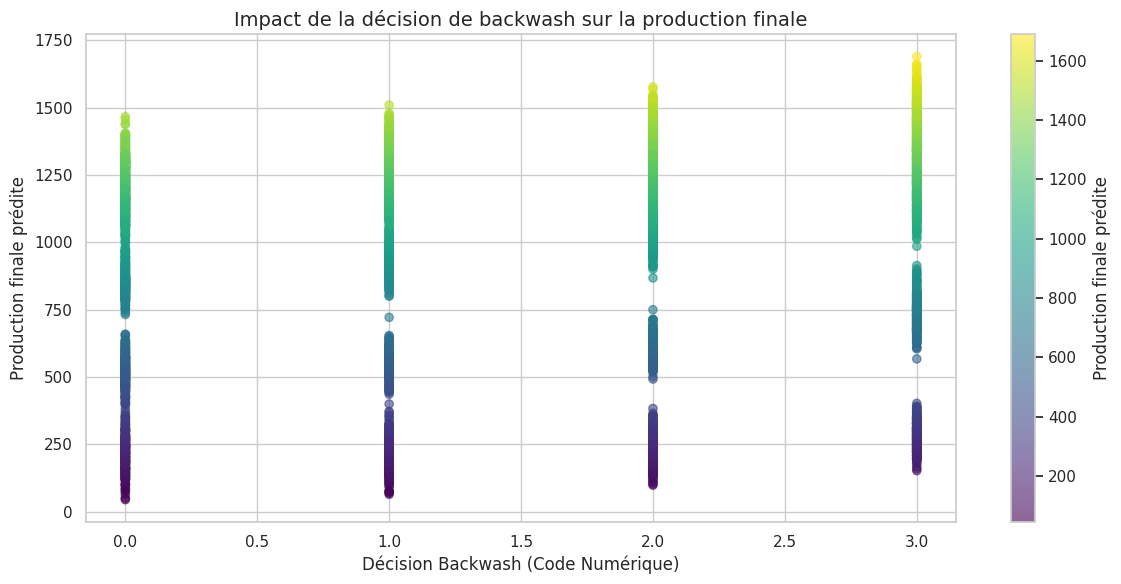

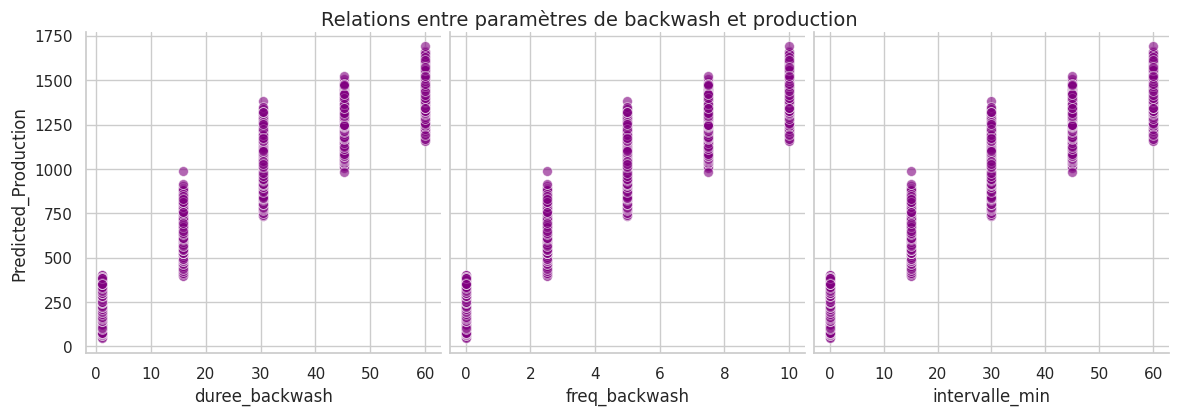

Top 200 combinaisons selon production finale prédite :


,DECISION_BACKWASH_NUM,duree_backwash,freq_backwash,intervalle_min,Predicted_Production
4089,3,60.00,10.0,60.0,1689.4976
3289,3,60.00,10.0,60.0,1661.5034
3569,3,60.00,10.0,60.0,1655.5619
3529,3,60.00,10.0,60.0,1652.8848
4049,3,60.00,10.0,60.0,1645.2269
3209,3,60.00,10.0,60.0,1636.8480
4064,3,60.00,10.0,60.0,1630.0022
3809,3,60.00,10.0,60.0,1616.2960
3544,3,60.00,10.0,60.0,1614.8734
4069,3,60.00,10.0,60.0,1611.1989


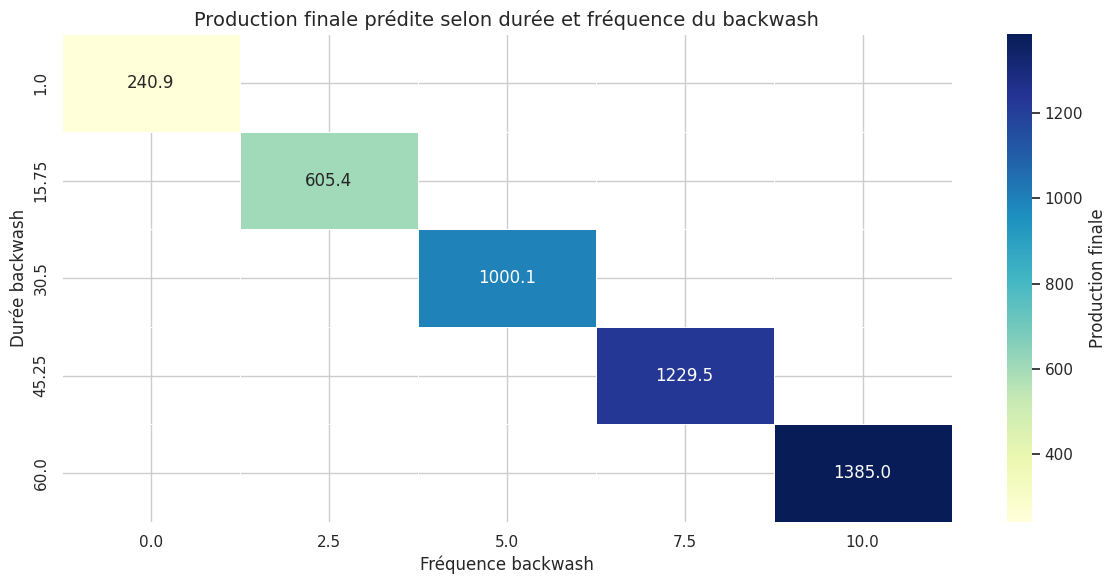

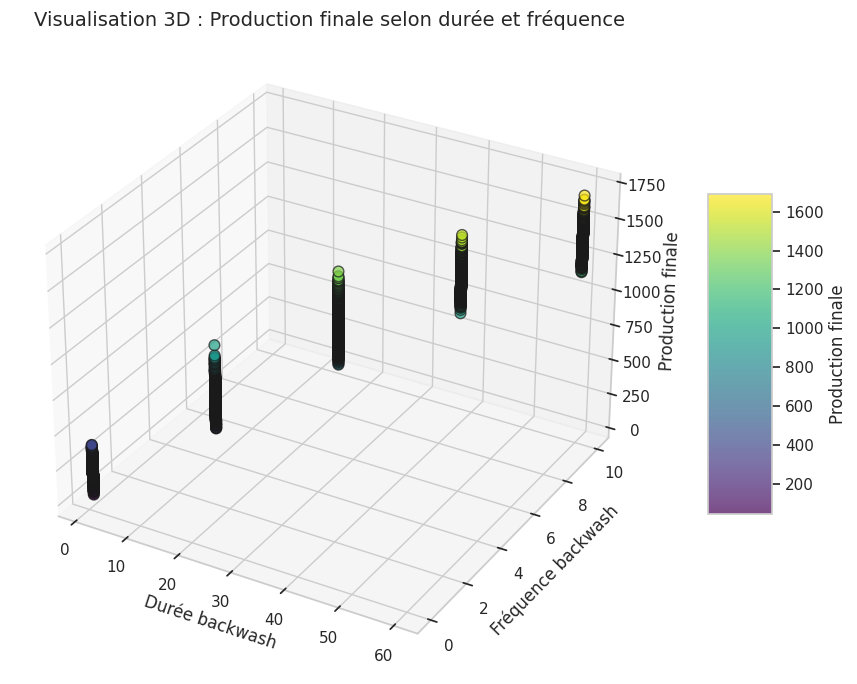

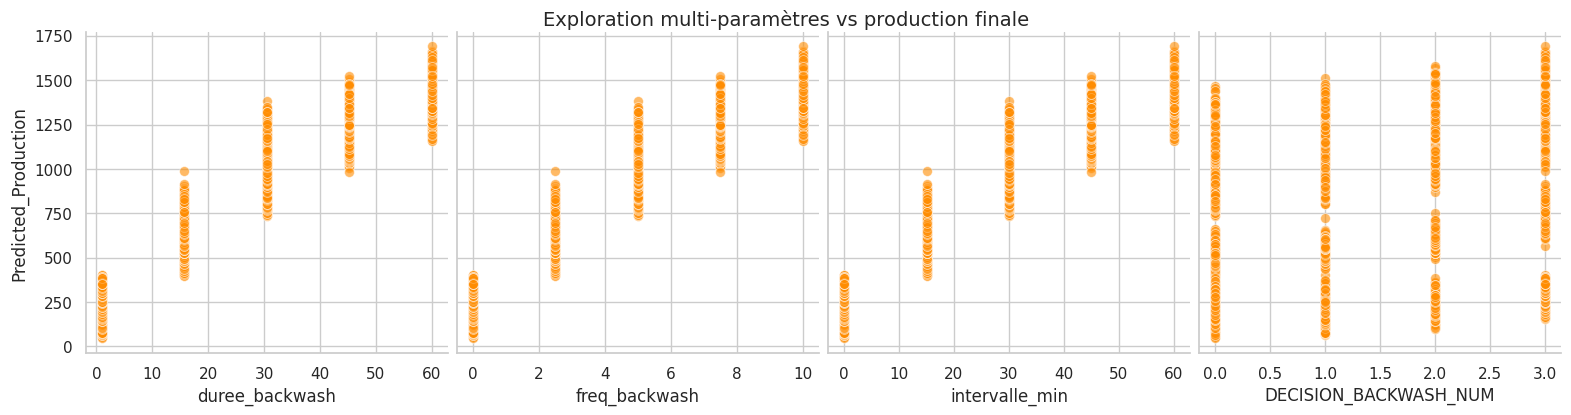

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np




pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# --- Style général ---
sns.set(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True})

# --- 0️⃣ Chargement du dataset avec prédictions ---
df_results = pd.read_csv('new_dataset_cascade_DL.csv')

# Renommer les colonnes pour cohérence avec ton code de visualisation
results_df = df_results.rename(columns={'prediction_DL':'Predicted_Production'})

# --- 0️⃣ Top N à afficher ---
top_n = 200  # nombre de meilleures combinaisons

# --- 1️⃣ Scatter : Production finale vs Décision Backwash ---
plt.figure(figsize=(12,6))
plt.scatter(results_df['DECISION_BACKWASH_NUM'], results_df['Predicted_Production'],
            alpha=0.6, c=results_df['Predicted_Production'], cmap='viridis')
plt.colorbar(label='Production finale prédite')
plt.xlabel('Décision Backwash (Code Numérique)')
plt.ylabel('Production finale prédite')
plt.title('Impact de la décision de backwash sur la production finale', fontsize=14)
plt.grid(True)
plt.show()

# --- 2️⃣ Pairplot simple pour explorer paramètres ---
sns.pairplot(
    results_df,
    x_vars=['duree_backwash','freq_backwash','intervalle_min'],
    y_vars='Predicted_Production',
    height=4,
    kind='scatter',
    plot_kws={'alpha':0.6, 's':50, 'color':'purple'}
)
plt.suptitle('Relations entre paramètres de backwash et production', y=1.02, fontsize=14)
plt.show()

# --- 3️⃣ Top N combinaisons selon production finale ---
top_df = results_df.sort_values('Predicted_Production', ascending=False).head(top_n)
print(f"Top {top_n} combinaisons selon production finale prédite :")
display(top_df[['DECISION_BACKWASH_NUM','duree_backwash','freq_backwash','intervalle_min','Predicted_Production']])

# --- 4️⃣ Heatmap : durée x fréquence du backwash ---
heat_df = results_df.pivot_table(
    values='Predicted_Production',
    index='duree_backwash',
    columns='freq_backwash',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label':'Production finale'})
plt.title("Production finale prédite selon durée et fréquence du backwash", fontsize=14)
plt.xlabel("Fréquence backwash")
plt.ylabel("Durée backwash")
plt.show()

# --- 5️⃣ 3D Scatter Plot décoré ---
X = results_df['duree_backwash']
Y = results_df['freq_backwash']
Z = results_df['Predicted_Production']

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X, Y, Z, c=Z, cmap=cm.viridis, s=60, alpha=0.7, edgecolors='k')
fig.colorbar(p, ax=ax, shrink=0.5, aspect=5, label='Production finale')
ax.set_xlabel('Durée backwash')
ax.set_ylabel('Fréquence backwash')
ax.set_zlabel('Production finale')
plt.title('Visualisation 3D : Production finale selon durée et fréquence', fontsize=14)
plt.show()

# --- 6️⃣ Pairplot multi-paramètres décoré ---
sns.pairplot(
    results_df,
    x_vars=['duree_backwash','freq_backwash','intervalle_min','DECISION_BACKWASH_NUM'],
    y_vars='Predicted_Production',
    height=4,
    kind='scatter',
    plot_kws={'alpha':0.6, 's':50, 'color':'darkorange'}
)
plt.suptitle('Exploration multi-paramètres vs production finale', y=1.02, fontsize=14)
plt.show()
